In [1]:
import pandas as pd

data = {
    "Hours":[1,2,3,4,5,6,7,8,9,10],
    "Attendance":[60,65,70,75,80,85,90,95,96,98],
    "Assignments":[40,45,55,60,70,75,80,85,90,95],
    "Pass":[0,0,0,0,1,1,1,1,1,1]
}

df = pd.DataFrame(data)

In [2]:
df

,Hours,Attendance,Assignments,Pass
0,1,60,40,0
1,2,65,45,0
2,3,70,55,0
3,4,75,60,0
4,5,80,70,1
5,6,85,75,1
6,7,90,80,1
7,8,95,85,1
8,9,96,90,1
9,10,98,95,1


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Hours        10 non-null     int64
 1   Attendance   10 non-null     int64
 2   Assignments  10 non-null     int64
 3   Pass         10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


,Hours,Attendance,Assignments,Pass
count,10.00000,10.000000,10.000000,10.000000
mean,5.50000,81.400000,69.500000,0.600000
std,3.02765,13.582669,18.922356,0.516398
min,1.00000,60.000000,40.000000,0.000000
25%,3.25000,71.250000,56.250000,0.000000
50%,5.50000,82.500000,72.500000,1.000000
75%,7.75000,93.750000,83.750000,1.000000
max,10.00000,98.000000,95.000000,1.000000


In [4]:
X = df[["Hours", "Attendance", "Assignments"]]
y = df["Pass"]

In [5]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    random_state= 42,
    test_size = 0.2
)

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train , y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [7]:
prediction = model.predict(X_test)

print(prediction)

[1 0]


In [11]:
new_student = pd.DataFrame({
    "Hours":[6],
    "Attendance":[82],
    "Assignments":[78]
})

result = model.predict(new_student)

if result[0] == 1:
    print("Student Will Pass")
else:
    print("Student Will Fail")

Student Will Pass


In [15]:
probability = model.predict_proba(new_student)

print(f"Fail Probability : {probability[0][0]*100:.2f}%")
print(f"Pass Probability : {probability[0][1]*100:.2f}%")

Fail Probability : 0.06%
Pass Probability : 99.94%


In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, prediction)

print(cm)

[[1 0]
 [0 1]]


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



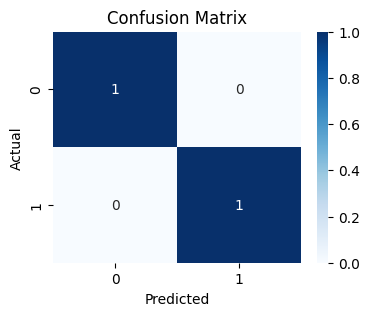

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

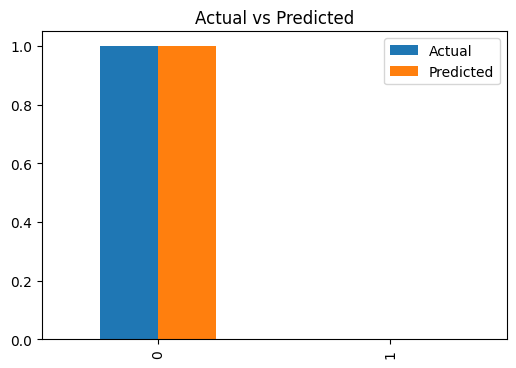

In [24]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": prediction
})

comparison.plot(kind="bar", figsize=(6,4))

plt.title("Actual vs Predicted")

plt.show()

In [25]:
coef = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_[0]
})

print(coef)

       Feature  Coefficient
0        Hours     0.049250
1   Attendance     0.246296
2  Assignments     0.480262


In [26]:
print(model.intercept_)

[-50.5262438]
